In [1]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
import sys
sys.path.append("..")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import accuracy_score, f1_score

from src.rl_agent import ThresholdEnv
from src.data_pipeline import encode_labels

In [2]:
# =========================
# CELL 2: LOAD DATA WITH NOTEBOOK-SAFE PATHS
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Classes:", class_names)

Train shape: (2684, 4)
Validation shape: (671, 4)
Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']


In [3]:
# =========================
# CELL 3: LOAD MODEL
# =========================
MODEL_PATH = "../experiments/results/best_efficientnetb0.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded.")

Model loaded.


In [4]:
# =========================
# CELL 4: PREPARE VALIDATION PROBABILITIES
# =========================
X_val = []
for path in val_df["full_path"]:
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    X_val.append(img.numpy())

X_val = np.array(X_val)

val_probs = model.predict(X_val, verbose=1)
val_pred = np.argmax(val_probs, axis=1)

base_acc = accuracy_score(y_val, val_pred)
base_f1 = f1_score(y_val, val_pred, average="macro")

print("Base Accuracy:", round(base_acc, 4))
print("Base Macro-F1:", round(base_f1, 4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 345ms/step
Base Accuracy: 0.2712
Base Macro-F1: 0.2366


In [5]:
# =========================
# CELL 5: CREATE ENVIRONMENT
# =========================
most_frequent_label = train_df["label"].mode()[0]
fallback_class = label_encoder.transform([most_frequent_label])[0]

env = ThresholdEnv(
    probs=val_probs,
    y_true=y_val,
    fallback_class=fallback_class
)

print("Threshold values:", env.threshold_values)
print("Fallback class:", class_names[fallback_class])
print("Base Macro-F1 at threshold 0.00:", round(env.evaluate_threshold(0.00), 4))

Threshold values: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95]
Fallback class: Healthy
Base Macro-F1 at threshold 0.00: 0.2366


In [6]:
# =========================
# CELL 6: SIMPLE Q-LEARNING RUN
# =========================
num_states = len(env.threshold_values)
num_actions = 3

Q = np.zeros((num_states, num_actions))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.98
epsilon_min = 0.05

episodes = 50
steps_per_episode = 10

episode_rewards = []
episode_thresholds = []
episode_f1s = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for _ in range(steps_per_episode):
        if random.random() < epsilon:
            action = random.randint(0, num_actions - 1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done, info = env.step(action)

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(float(total_reward))
    episode_thresholds.append(float(info["threshold"]))
    episode_f1s.append(float(info["macro_f1"]))

    print(
        f"Episode {episode+1:02d} | "
        f"Threshold: {info['threshold']:.2f} | "
        f"Macro-F1: {info['macro_f1']:.4f} | "
        f"Reward: {total_reward:.4f} | "
        f"Epsilon: {epsilon:.4f}"
    )

Episode 01 | Threshold: 0.50 | Macro-F1: 0.1794 | Reward: 0.0000 | Epsilon: 0.9800
Episode 02 | Threshold: 0.70 | Macro-F1: 0.1534 | Reward: -0.0260 | Epsilon: 0.9604
Episode 03 | Threshold: 0.65 | Macro-F1: 0.1536 | Reward: -0.0258 | Epsilon: 0.9412
Episode 04 | Threshold: 0.65 | Macro-F1: 0.1536 | Reward: -0.0258 | Epsilon: 0.9224
Episode 05 | Threshold: 0.45 | Macro-F1: 0.2185 | Reward: 0.0391 | Epsilon: 0.9039
Episode 06 | Threshold: 0.40 | Macro-F1: 0.2473 | Reward: 0.0679 | Epsilon: 0.8858
Episode 07 | Threshold: 0.40 | Macro-F1: 0.2473 | Reward: 0.0679 | Epsilon: 0.8681
Episode 08 | Threshold: 0.45 | Macro-F1: 0.2185 | Reward: 0.0391 | Epsilon: 0.8508
Episode 09 | Threshold: 0.05 | Macro-F1: 0.2366 | Reward: 0.0572 | Epsilon: 0.8337
Episode 10 | Threshold: 0.40 | Macro-F1: 0.2473 | Reward: 0.0679 | Epsilon: 0.8171
Episode 11 | Threshold: 0.45 | Macro-F1: 0.2185 | Reward: 0.0391 | Epsilon: 0.8007
Episode 12 | Threshold: 0.35 | Macro-F1: 0.2456 | Reward: 0.0662 | Epsilon: 0.7847
E

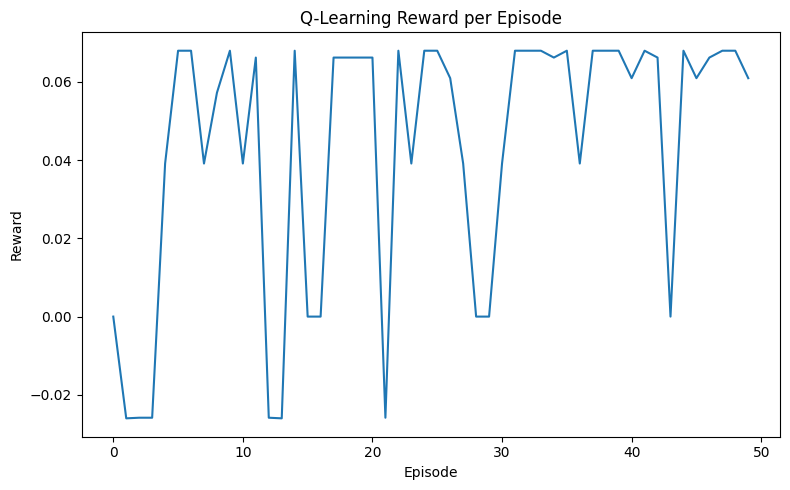

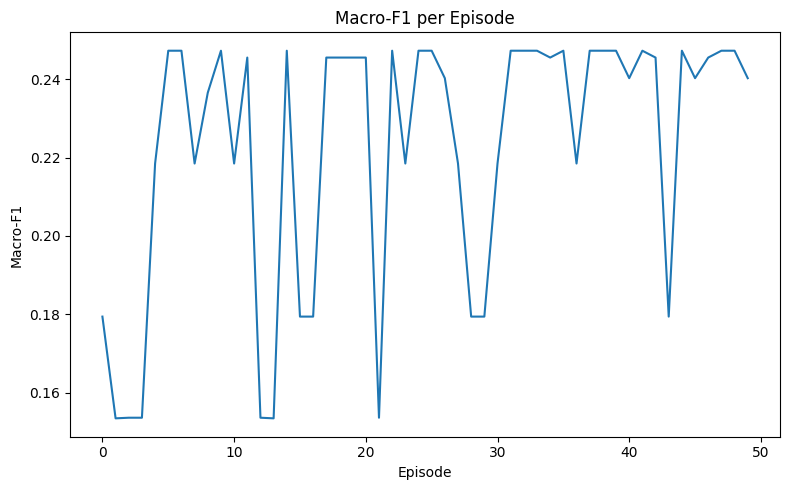

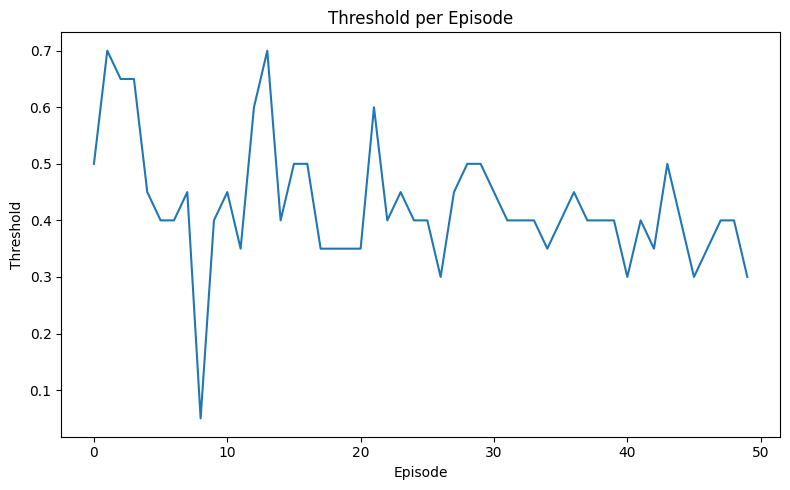

In [7]:
# =========================
# CELL 7: LEARNING CURVES
# =========================
plt.figure(figsize=(8, 5))
plt.plot(episode_rewards)
plt.title("Q-Learning Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(episode_f1s)
plt.title("Macro-F1 per Episode")
plt.xlabel("Episode")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(episode_thresholds)
plt.title("Threshold per Episode")
plt.xlabel("Episode")
plt.ylabel("Threshold")
plt.tight_layout()
plt.show()

In [8]:
# =========================
# CELL 8: BEST RESULT
# =========================
best_episode_idx = int(np.argmax(episode_f1s))
best_threshold = episode_thresholds[best_episode_idx]
best_f1 = episode_f1s[best_episode_idx]

print("CNN Base Macro-F1 :", round(base_f1, 4))
print("RL Best Macro-F1  :", round(best_f1, 4))
print("Best Threshold    :", best_threshold)

CNN Base Macro-F1 : 0.2366
RL Best Macro-F1  : 0.2473
Best Threshold    : 0.4


In [9]:
# =========================
# CELL 9: OPTIONAL READ SAVED RL RESULTS
# =========================
rl_results_path = Path("../experiments/results/rl_results.json")

if rl_results_path.exists():
    with open(rl_results_path, "r") as f:
        saved_rl = json.load(f)

    pd.DataFrame([saved_rl])
else:
    print("No saved RL results found yet.")

In [10]:
# =========================
# CELL 10: OPTIONAL SHORT SUMMARY
# =========================
print("Summary:")
print("- The RL component uses Q-learning to tune the classification threshold.")
print("- The state represents the current threshold value.")
print("- Actions adjust the threshold up, down, or keep it unchanged.")
print("- Reward is based on the improvement in validation macro-F1.")

Summary:
- The RL component uses Q-learning to tune the classification threshold.
- The state represents the current threshold value.
- Actions adjust the threshold up, down, or keep it unchanged.
- Reward is based on the improvement in validation macro-F1.
